# Module 2: Programming Assignment

In [3]:
library(testthat)
library(ggplot2)

expect_constant = function(actual, tolerance = .Machine$double.eps^0.5) {
  if (length(actual) == 0) {
    fail("The vector is empty.")
  }
  
  # Check if all elements are the same within the given tolerance
  if (all(abs(actual - actual[1]) < tolerance)) {
    succeed()
  } else {
    fail("Your answer is not proportional to the posterior.")
  }
}

## Problem 1: Inference on the number of trials in a binomial

Let $n$ be the unknown number of customers that visit a store on the day of a sale. The number of customers that make a purchase is $Y \, | \, n \sim Binomial(n, \theta)$, where $\theta$ is the *known* probability of making a purchase, given that the customer visited the store. The prior is $n \sim Poisson(10)$. 

**1 (a) [4 points] Plot the prior distribution for integers `n = 0:30` using ggplot2. Follow these steps:** 

- First, using the `dpois()` function, store the values for the prior ($n \sim Poisson(10)$) in variable `prior`. 

- Then, create a dataframe labelled `df` with columns `n` and `prior`. 

- Finally, create and ggplot bar plot (using `geom_bar(stat="identity")`) labelled `p`.

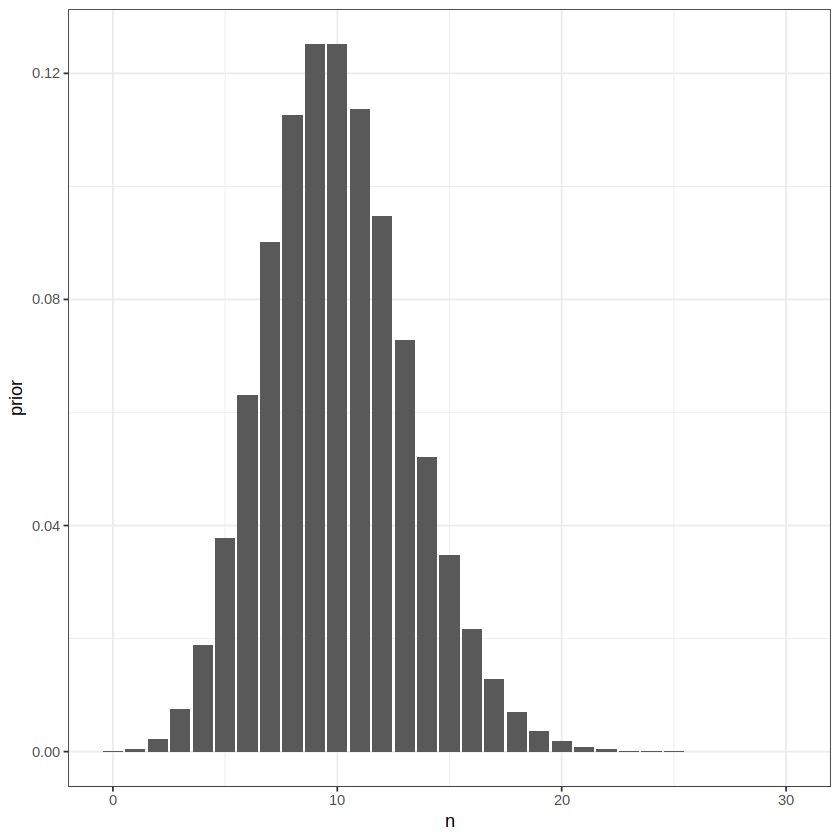

In [4]:
n = 0:30
prior = dpois(n, 10)
df = data.frame(n=n, prior=prior)
p = ggplot(df, aes(n, prior)) + geom_bar(stat='identity') + theme_bw()
p
# your code here
#.NotYetImplemented()

**1 (b) [6 points] Assuming $\theta = 0.2$ is known, and that there were $y = 5$ purchases on the day of the sale, compute the posterior distribution for $n \, | \, y$ with the following steps:** 

- Compute a "likelihood vector", `l`, where the $i^{th}$ entry ($i = 0,...,30$) of the vector is the probability mass value for the data `y = 5` and `theta =  0.2`. 

- Compute a "posterior vector" , `posterior1`, where the $i^{th}$ entry ($i = 0,...,30$) of the vector is the posterior probability mass value for the data `y = 5` and `theta =  0.2`. Note that you can easily compute the denominator of Bayes' theorem using `sum(prior*l)`. 

- Plot the posterior distribution. 

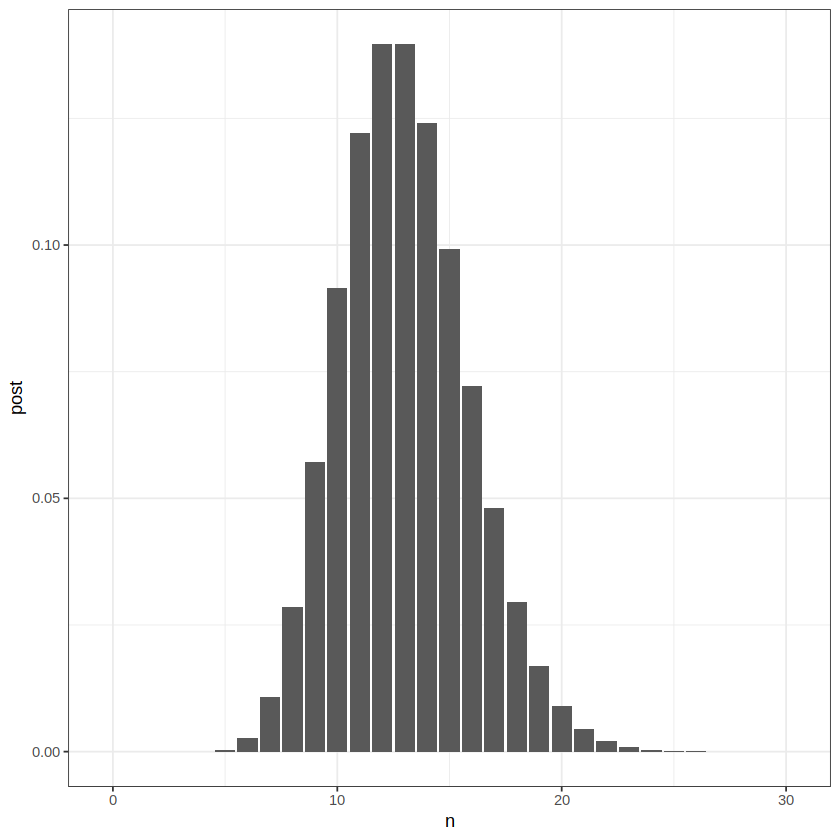

In [14]:
theta = 0.2
y = 5
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
posterior1 = prior*l / sum(prior*l)
#sum(n*posterior1)
#posterior1
#sum(posterior1)
#df = data.frame(n=n, prior=prior, ll=l, post=posterior1)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, post=posterior1)
p = ggplot(df, aes(n, post)) + 
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()

**1 (c) [4 points] Assuming $\theta = 0.2$ is known, but now assuming that there were $y = 10$ purchases on the day of the sale, compute the posterior distribution for $n \, | \, y$. Use the same process as given in 1 (b), but store the posterior vector in `posterior2`.**

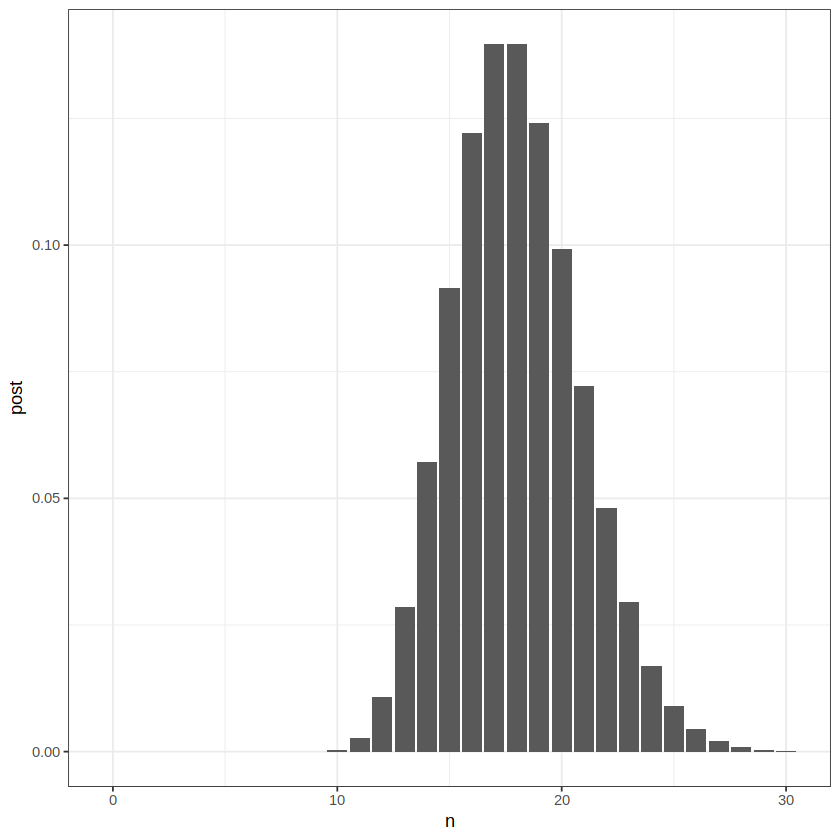

In [15]:
y = 10 
theta = 0.2
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
#print(l)
posterior2 = prior*l / sum(prior*l)
#sum(n*posterior2)
#df = data.frame(n=n, prior=prior, ll=l, post=posterior2)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, prior=prior, ll=l, post=posterior2)
p = ggplot(df, aes(n, post)) +
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()

**1 (d) [4 points] Again, assuming $\theta = 0.2$ is known, but now assuming that there were $y = 15$ purchases on the day of the sale, compute the posterior distribution for $n \, | \, y$.** 

**Start by creating variables `theta` and `y` and assigning these variables with the values $0.2$ and $15$, respectively. Calculate the likelihood function for $n = 0:30$ and store it as a variable `l`. Calculate the posterior and store it as a variable `posterior3`. Finally, using ggplot2, create and plot a plot of the posterior labelled `p`. How does the plot of the posterior compare to the plot of the  prior distribution? How does it compare to the prior distribution and the posterior from the previous part?**

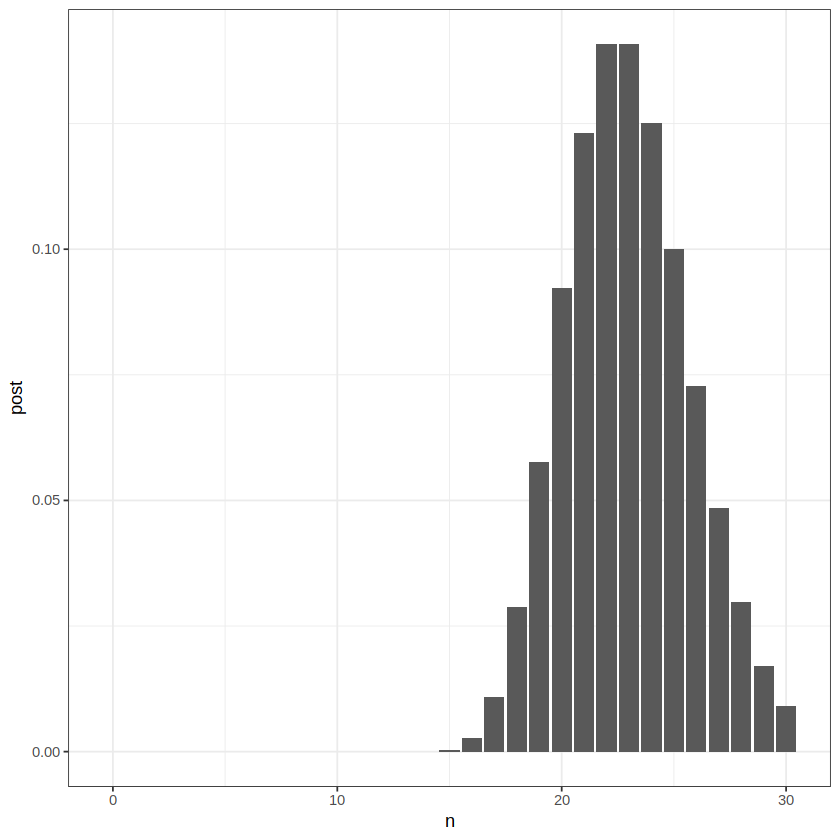

In [16]:
y = 15 
theta = 0.2
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
posterior3 = prior*l / sum(prior*l)
#sum(n*posterior3)

#df = data.frame(n=n, prior=prior, ll=l, post=posterior3)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, post=posterior3)
p = ggplot(df, aes(n, post)) +
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()


**1 (e) [8 points] Answer `TRUE` or `FALSE` for each of the following questions i. - iv. Submit your answer to each by replacing the `NA`values in the code cell below with your answer to the corresponding question.**

i. When compared with the prior, the mean of the posterior distribution for $\theta = 0.2$, $y = 5$ shifted downward, because the data $y = 5$ suggests that $n$ is likely smaller than was thought under the prior distribution.

ii. When compared to the prior, the mean of the posterior distribution for $\theta = 0.2$, $y = 10$ shifted upward, because the data $y = 10$ suggests that $n$ is likely larger than was thought under the prior distribution.

iii. When compared to the posterior for $\theta = 0.2$, $y = 5$, the mean of the posterior distribution for $\theta = 0.2$, $y = 10$ is larger, because the data $y = 10$ suggests that $n$ is likely larger than the data $y = 5$.

iv. When compared to the posterior for $\theta = 0.2$, $y = 10$, the mean of the posterior distribution for $\theta = 0.2$, $y = 15$ is smaller, because the data $y = 15$ suggests that $n$ is likely larger than the data $y = 10$.


In [ ]:
i = FALSE
ii = TRUE
iii = TRUE
iv = FALSE

# your code here
#.NotYetImplemented()

**1 (f) [3 points] Repeat part (b) for $\theta = 0.8$.**

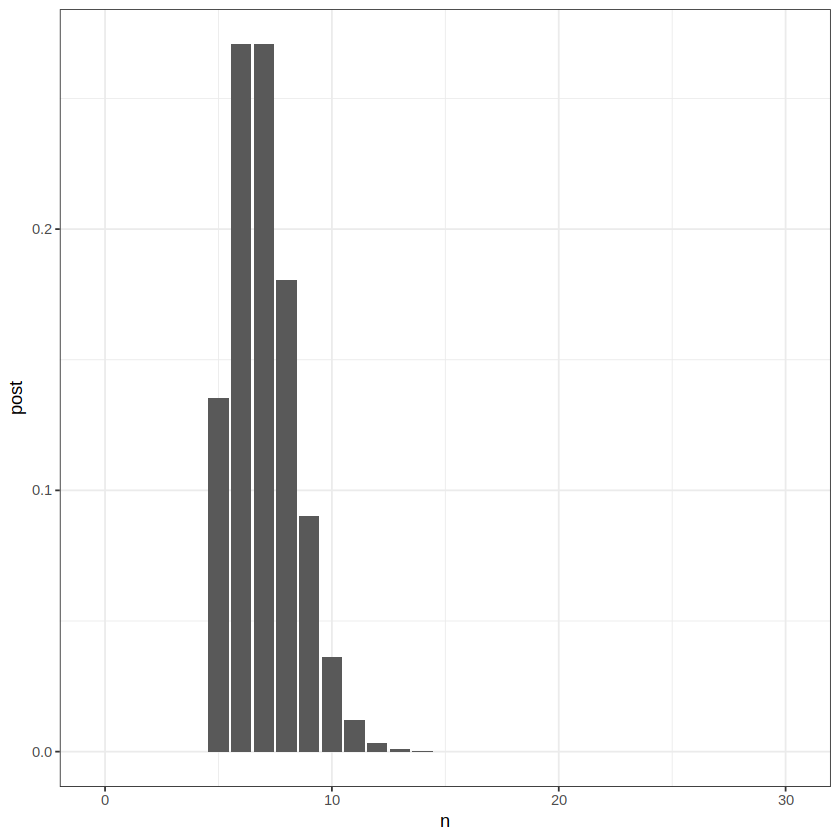

In [17]:
y = 5 
theta = 0.8
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
posterior4 = prior*l / sum(prior*l)
#posterior4
#sum(n*posterior4)

#df = data.frame(n=n, prior=prior, ll=l, post=posterior4)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, post=posterior4)
p = ggplot(df, aes(n, post)) +
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()

**1 (g) [3 points] Repeat part (c) for $\theta = 0.8$.**

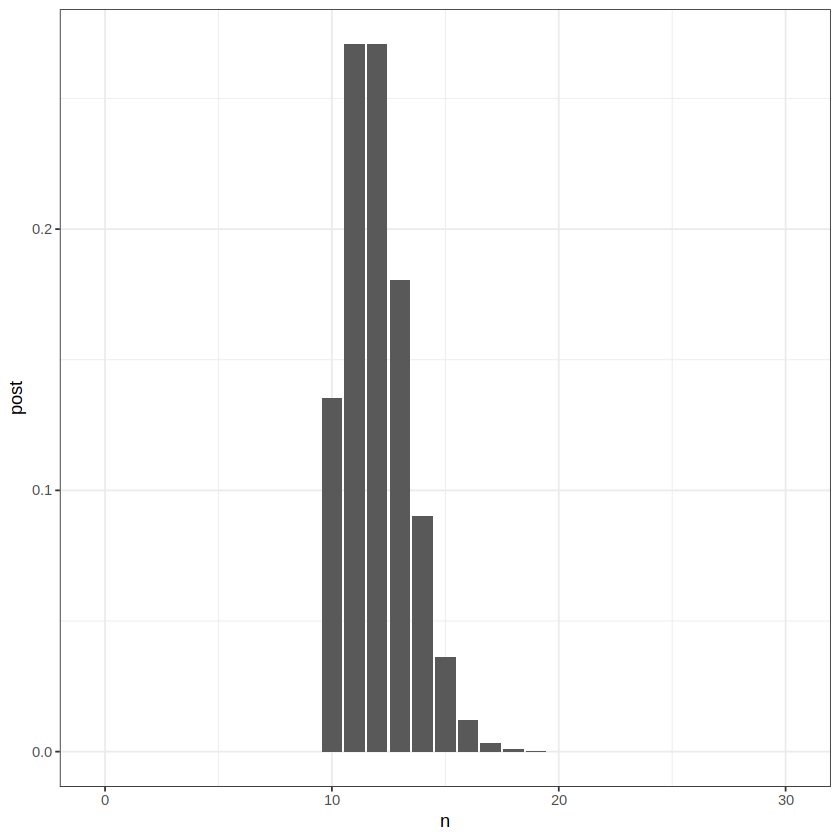

In [18]:
y = 10 
theta = 0.8
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
posterior5 = prior*l / sum(prior*l)
#posterior5
#sum(n*posterior5)

#df = data.frame(n=n, prior=prior, ll=l, post=posterior5)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, post=posterior5)
p = ggplot(df, aes(n, post)) +
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()

**1 (h) [3 points] Repeat part (d) for $\theta = 0.8$.**

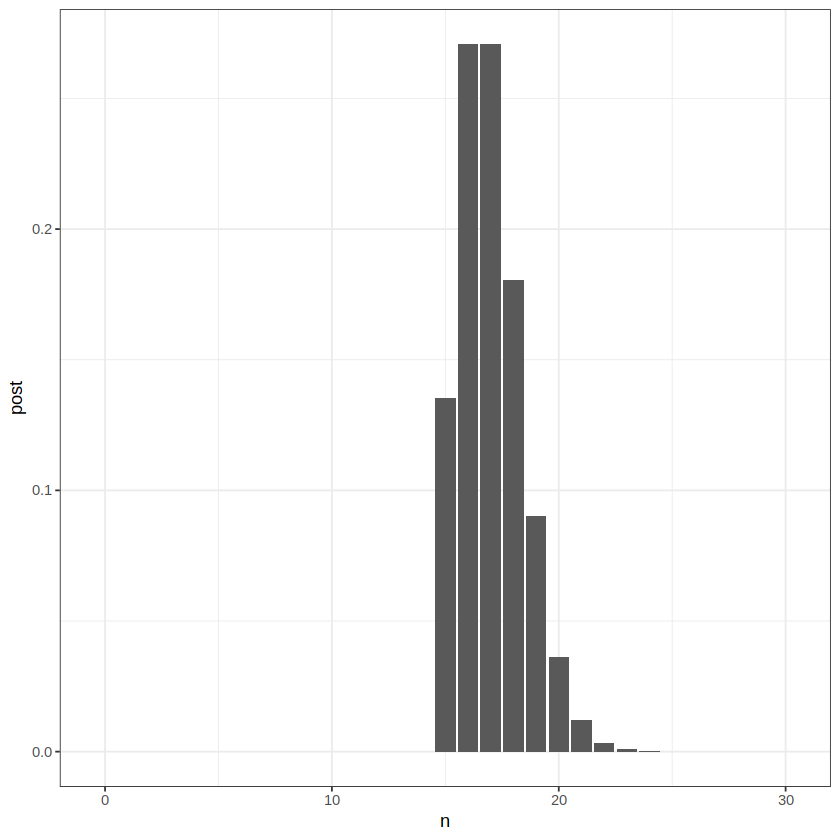

In [19]:
y = 15 
theta = 0.8
#l = choose(n, y)*theta^y*(1-theta)^(n-y)
l <- dbinom(y, size = n, prob = theta)
posterior6 = prior*l / sum(prior*l)
#posterior6
#sum(n*posterior6)

#df = data.frame(n=n, prior=prior, ll=l, post=posterior6)
#p = ggplot(df) +
    #geom_line(aes(n, prior, col='prior')) +
    #geom_line(aes(n, ll, color='likelihood')) +
    #geom_line(aes(n, post, color='posterior')) +
    #theme_bw()
df = data.frame(n=n, post=posterior6)
p = ggplot(df, aes(n, post)) +
    geom_bar(stat='identity') +
    theme_bw()
p

# your code here
#.NotYetImplemented()

**1 (i) [6 points] Answer `TRUE` or `FALSE` for each of the following questions i., ii., and iii. Submit your answer to each by replacing the `NA`values in the code cell below with your answer to the corresponding question.**

i. When $\theta = 0.8$ and $y = 5$, the posterior distribution has no probability mass above $n \in \{1,2,3,4\}$ because it is not possible for $n \ge 5$ when $\theta = 0.8,\,\,y = 5$. 

ii. When $\theta = 0.8$ and $y = 15$, the posterior distribution has no probability mass below $n \in \{1,2,3,4\}$ because it is not possible for $n < 15$ when $\theta = 0.8,\,\, y = 15$.

iii. When $\theta = 0.8$ and $y = 5$, the posterior distribution mode is approximately $5$. 

In [ ]:
i = FALSE
ii = TRUE
iii = FALSE

# your code here
#.NotYetImplemented()